# Example Mechanistic interpretation with Indra

# Dataset background
- The NHLBI-BDC has five [training studies](https://biodatacatalyst.nhlbi.nih.gov/about/studies/?program=Training) (They do not list digitalis here for some reason...)
- For this example we will consider the `biolincc_digitalis` training study ([more information](https://biolincc.nhlbi.nih.gov/media/teachingstudies/digdoc.pdf?link_time=2026-05-29_14:40:07.800080))
- This is a fully-anonymized training dataset derived from the Digitalis Investigation Group (DIG) clinical trial, which was a random ized, double-blind, multicenter trial with more than 300 centers in the United States and Canada participating. The purpose of the trial was to examine the safety and efficacy of Digoxin in treating patients with congestive heart failure in sinus rhythm.
- The data set was designed in such a way to allow students to reproduce the results from [The Effect of Digoxin on Mortality and Morbidity in Patients with Heart Failure](https://www.nejm.org/doi/full/10.1056/NEJM199702203360801) by the DIG group.

## Outline
The proceeding analysis will be conducted in three steps:
1. Use the `gen3` client to pull data from the BDC API.
2. Use `lifelines` to replicate some of the findings from [The Effect of Digoxin on Mortality and Morbidity in Patients with Heart Failure](https://www.nejm.org/doi/full/10.1056/NEJM199702203360801)
3. Use `indra` to derive a mechanistic interpretation of results.

## Step 1 pull data
- Here we will use the [Gen3 Python SDK](https://docs.gen3.org/gen3-resources/tools/gen3-sdk/) to pull a `.csv` version of the biolincc_digitalis dataset.
- First we must authenticate to the Gen3 BDC client. Such a key can be obtained by creating an account on the [Gen3 BDC developer portal](https://gen3.biodatacatalyst.nhlbi.nih.gov/login) 

In [1]:
COMMONS = 'https://gen3.biodatacatalyst.nhlbi.nih.gov'
CRED_FILE = '/Users/buzgalbraith/.gen3/credentials.json' ## make sure this matches your location'

In [2]:
from gen3.auth import Gen3Auth
auth = Gen3Auth(endpoint=COMMONS, refresh_file=CRED_FILE)

Now we can download the file and save it to `./data`


In [3]:
from gen3.tools.download.drs_download import DownloadManager, Downloadable
import os 
object_id = 'dg.4503/4a871b36-54d3-485e-b19a-19f499984a9e'
manager = DownloadManager(
            hostname=COMMONS.removeprefix("https://"),
            auth=auth,
            download_list=[Downloadable(object_id)],
)
os.makedirs('./data', exist_ok=True)
manager.download(manager.download_list, save_directory='./data')

[2026-05-29 17:21:59,570][WARNING] HTTP Error (502) from 'https://gen3.biodatacatalyst.nhlbi.nih.gov/wts/external_oidc/': {'error': 'service failure - try again later'}. Likely no WTS service running on this Commons. Proceeding, but certain commands might fail.


{'dg.4503/4a871b36-54d3-485e-b19a-19f499984a9e': filename: xfer_dig_teaching_v2021_07_15.csv; status: downloaded; start_time: 05/29/2026, 21:22:02; end_time: 05/29/2026, 21:22:02}

## Step 2. 
Now we will analyze the dataset to access the effect of digoxin on health outcomes. We will be reproducing the analysis from [The Effect of Digoxin on Mortality and Morbidity in Patients with Heart Failure](https://www.nejm.org/doi/full/10.1056/NEJM199702203360801)

First lets load and get a sense of the data.

In [4]:
import pandas as pd
df = pd.read_csv('./data/xfer_dig_teaching_v2021_07_15.csv')
df.head()

,ID,TRTMT,AGE,RACE,SEX,EJF_PER,EJFMETH,CHESTX,BMI,KLEVEL,...,OTH,OTHDAYS,HOSP,HOSPDAYS,NHOSP,DEATH,DEATHDAY,REASON,DWHF,DWHFDAYS
0,1,0,66,1,1,40,2,0.50,20.073,NaN,...,1,533,1,533,6,0,1438,NaN,1,1379
1,2,0,77,1,1,12,1,0.56,20.701,3.1,...,1,880,1,468,4,1,1360,1.0,1,1329
2,3,0,72,1,2,36,1,0.68,25.530,5.1,...,0,1391,1,631,2,0,1391,NaN,1,631
3,4,1,57,1,1,31,1,0.48,25.794,NaN,...,0,1157,0,1157,0,0,1157,NaN,0,1157
4,5,0,74,1,1,15,1,0.53,25.654,4.0,...,1,459,1,191,5,0,1550,NaN,1,191


Our dataset has the following relevant variables.
- `TRTMT` treatment indicator - 0 indicated receiving placebo 1 indicates receiving digoxin.
- `DEATH` indicator for if the patient died during the observation period. 
- `DEATHDAY` numeric day in which the patient died (if they did).
- `DWHF` indicator for if the patient died of heart failure during the observation period. 
- `DWHFDAYS` numeric day in which the patient died of heart failure (if they did)

Let set up our survival analysis. See [The Effect of Digoxin on Mortality and Morbidity in Patients with Heart Failure](https://www.nejm.org/doi/full/10.1056/NEJM199702203360801) for more information.

In [5]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np

trt = 'TRTMT' 
def survival_by_arm(df, duration, event, title):
    """KM curves + log-rank + treatment-only Cox HR for one endpoint."""
    d = df[[duration, event, trt]].dropna() 
    placebo = d[d[trt] == 0]
    digoxin = d[d[trt] == 1]

    kmf = KaplanMeierFitter()
    ax = plt.subplot(111)
    kmf.fit(placebo[duration], placebo[event], label="placebo").plot_survival_function(ax=ax)
    kmf.fit(digoxin[duration], digoxin[event], label="digoxin").plot_survival_function(ax=ax)
    ax.set_title(title); ax.set_xlabel("days"); ax.set_ylabel("event-free probability")
    plt.show()

    lr = logrank_test(placebo[duration], digoxin[duration],
                      placebo[event], digoxin[event])
    cph = CoxPHFitter().fit(d, duration_col=duration, event_col=event)
    hr = np.exp(cph.params_[trt])
    lo, hi = np.exp(cph.confidence_intervals_.loc[trt])
    print(f"{title}")
    print(f"  log-rank p = {lr.p_value:.4f}")
    print(f"  HR (digoxin vs placebo) = {hr:.3f}  (95% CI {lo:.3f}-{hi:.3f}), "
          f"p = {cph.summary.loc[trt, 'p']:.4f}\n")
    return hr, cph.summary.loc[trt, "p"]


Lets look at the difference between the treatment and placebo group in terms of overall mortality. See mortality section of [The Effect of Digoxin on Mortality and Morbidity in Patients with Heart Failure](https://www.nejm.org/doi/full/10.1056/NEJM199702203360801) for more information.

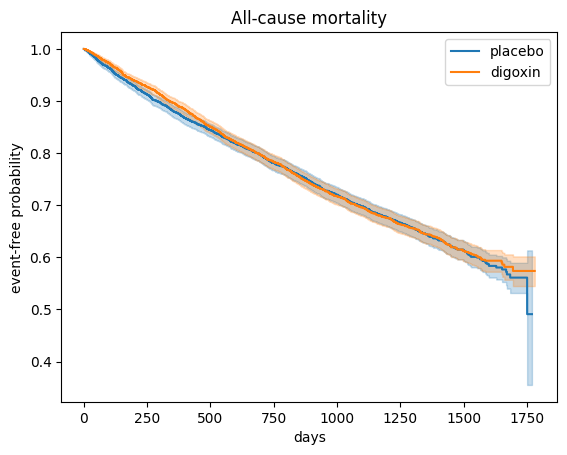

All-cause mortality
  log-rank p = 0.8013
  HR (digoxin vs placebo) = 0.990  (95% CI 0.913-1.073), p = 0.8014



(np.float64(0.9897291084180894), np.float64(0.8013846154489443))

In [6]:
survival_by_arm(df, 'DEATHDAY', 'DEATH', "All-cause mortality")

This test yields a p-value ~0.8, so we can not reject the null hypothesis at any reasonable confidence level. 
Thus we can not say that digoxin had an effect on overall mortality.

Now lets conduct sub-group analysis to only compare deaths from heart failure between our treatment and control groups

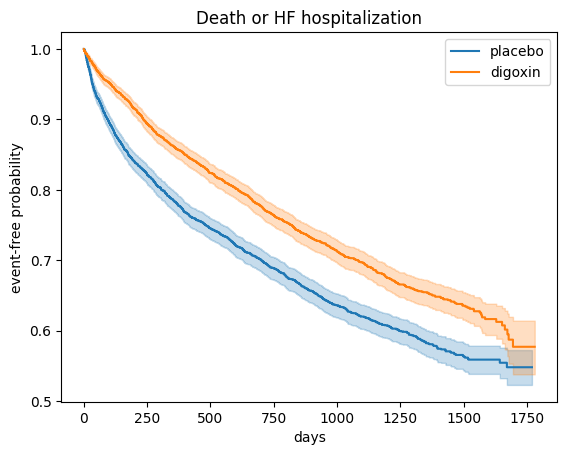

Death or HF hospitalization
  log-rank p = 0.0000
  HR (digoxin vs placebo) = 0.753  (95% CI 0.694-0.817), p = 0.0000



(np.float64(0.7532149019402862), np.float64(1.0247759267338944e-11))

In [7]:
survival_by_arm(df, 'DWHFDAYS', 'DWHF', "Death or HF hospitalization")


Here we can see there is a statically significant difference between the rates of death from heart failure between our treatment and control with a high level of confidence.

This may lead one to ask, has anyone else observed this relationship or are the molecular mechanisms under-pinning this effect? Indra can help answer such questions. 

## step 3. Using Indra to interpret these results
Lets first retrieve all statements Indra statements involving digoxin 

In [8]:
from indra.sources import indra_db_rest
ip = indra_db_rest.get_statements(subject='digoxin', ev_limit=None)
stmts = ip.statements
print(f"retrieved {len(stmts)} statements mentioning digoxin\n")

INFO: [2026-05-29 17:22:03] indra_db_rest.query_processor - Retrieving statements that have an agent where NAME=digoxin with role=SUBJECT.
INFO: [2026-05-29 17:22:03] indra_db_rest.request_logs - Running 0th request for statements
INFO: [2026-05-29 17:22:03] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-05-29 17:22:03] indra_db_rest.request_logs -   OFFSET: 0
INFO: [2026-05-29 17:22:10] indra_db_rest.request_logs - Running 1st request for statements
INFO: [2026-05-29 17:22:10] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-05-29 17:22:10] indra_db_rest.request_logs -   OFFSET: 500
INFO: [2026-05-29 17:22:17] indra_db_rest.request_logs - Running 2nd request for statements
INFO: [2026-05-29 17:22:17] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-05-29 17:22:17] indra_db_rest.request_logs -   OFFSET: 1000
INFO: [2026-05-29 17:22:24] indra_db_rest.request_logs - Running 3rd request for statements
INFO: [2026-05-29 17:22:24] indra_db_rest.request_logs -   LIMIT: No

retrieved 1973 statements mentioning digoxin



Lets use Indra to understand some of these statements.

In [9]:
from indra.assemblers.english import EnglishAssembler
for st in stmts[:5]:
    print("  -", EnglishAssembler([st]).make_model())

  - Digoxin inhibits Heart Failure.
  - Fab binds digoxin.
  - Digoxin inhibits Neoplasms.
  - Digoxin inhibits XK.
  - Digoxin inhibits sodium atom.


We can see that Indra returns a statement supporting our finding that digoxin inhibits heart failure. 
Let's see how well this is supported by the literature.

In [10]:
pmids = {ev.pmid for ev in hf.evidence}
print(f"There are {len(pmids)} articles supporting supporting the notion that digoxin inhibits heart failure on PubMed")

NameError: name 'hf' is not defined

- So this is a fairly well established idea. 
- Let's try to get a sense of what the molecular basis of this relationship is.
- We can gather the gene or protein, and retrieve there evidence counts

In [ ]:
from collections import Counter
targets = Counter()
for st in stmts:
    for ag in st.agent_list():
        if ag is not None and "HGNC" in ag.db_refs and ag.name.lower() != "digoxin":
            targets[ag.name] += 1
print(f'Indra has relations between digoxin and {len(targets)} targets')

Indra has relations between digoxin and 288 genes/proteins


- Indra has relationships between digoxin and almost 300 targets.
- Let's take a look at the most well supported of these targets

In [ ]:
print("top digoxin targets in INDRA:")
for name, n in targets.most_common(10):
    print(f"  {name}\t  ({n} statements)")

top digoxin targets in INDRA:
  HIF1A	  (11 statements)
  SRC	  (10 statements)
  IL17A	  (8 statements)
  ABCB1	  (7 statements)
  TP53	  (7 statements)
  STAT3	  (7 statements)
  TAC1	  (7 statements)
  SRSF3	  (6 statements)
  PGP	  (6 statements)
  REN	  (6 statements)


Here we can see that we have a number of targets with high evidence counts.
We can use the Indra CoGEx knowledge graph to retrieve molecular pathways for this set of genes.

In [ ]:
import requests
N = 15
endpoint = "https://discovery.indra.bio/api/discrete_analysis"
genes = [name for name, _ in targets.most_common(N)]
print("Finding pathways for gene set containing:", genes)

resp = requests.post(endpoint, json={"gene_list": genes} )
resp.raise_for_status()
result = resp.json()

## display results ## 
for category, rows in result.items():
    pkey = next((k for k in ("q", "qval", "p", "pval") if k in rows[0]), None)
    ordered = sorted(rows, key=lambda r: r.get(pkey, 1.0)) if pkey else rows
    print(f"\n=== {category} ({len(rows)} terms) ===")
    for r in ordered[:8]:
        name = r.get("name") or r.get("label") or r.get("id") or "?"
        score = f"  ({pkey}={r[pkey]:.2e})" if pkey and pkey in r else ""
        print(f"  {name}{score}")



Finding pathways for gene set containing: ['HIF1A', 'SRC', 'IL17A', 'ABCB1', 'TP53', 'STAT3', 'TAC1', 'SRSF3', 'PGP', 'REN', 'XK', 'NFE2L2', 'TNF', 'NDRG1', 'KCNH2']

=== go (197 terms) ===
  positive regulation of cytokine production involved in inflammatory response  (q=7.46e-08)
  cellular response to cytokine stimulus  (q=2.58e-07)
  response to cytokine  (q=4.40e-07)
  regulation of cytokine production involved in inflammatory response  (q=1.06e-06)
  enzyme binding  (q=1.33e-06)
  positive regulation of miRNA transcription  (q=2.13e-06)
  positive regulation of miRNA metabolic process  (q=3.13e-06)
  cellular response to hypoxia  (q=8.20e-06)

=== phenotype (29 terms) ===
  Phenotypic abnormality  (q=2.65e-03)
  All  (q=2.65e-03)
  Autosomal dominant inheritance  (q=4.43e-03)
  Mendelian inheritance  (q=8.48e-03)
  Mode of inheritance  (q=8.48e-03)
  Myelofibrosis  (q=1.24e-02)
  Abnormality of metabolism/homeostasis  (q=1.31e-02)
  Abnormal large intestine morphology  (q=1.31e-0

- Here we can see some well attested pathways for multiple such genes. 
- This is good to know, but suppose we are more interested in the specific question of " which kineses are inhibited by digoxin"
- We can again use Indra to analyze this

In [ ]:
from indra.statements import *
from indra.databases import hgnc_client

gene_list = []
for stmt in stmts:
    if isinstance(stmt, Inhibition):
        if stmt.obj.db_refs.get('HGNC'):
            if hgnc_client.is_kinase(stmt.obj.name):
                gene_list.append(stmt.obj.name)
print(gene_list)

['SRC', 'CDK4', 'STK11', 'MLKL', 'PTK2', 'MTOR', 'STK11', 'SRC', 'CDK1', 'CDK6', 'EGFR', 'GSK3B']
